#script name is misnomer?? do you mean: plot mean of well?

In [1]:
import pandas as pd
from pathlib import Path
from matplotlib import pyplot as plt
import numpy as np
%load_ext watermark #note that if one transfers this script from Python, the % lines have to be fired from the console and commented out in the script
%watermark -v -p pandas,matplotlib,numpy

CPython 3.7.7
IPython 7.17.0

pandas 1.0.4
matplotlib 3.1.3
numpy 1.16.6


 #make sure to point the path to your local copy of surfdrive, NOT to the surdrive shortcut in explorer

In [2]:
base_path = Path('E:\\','LocalSurfDrive', 'Shared', 'Screening_Data_Mutable')
tau_pth = Path(base_path,'2019','12','05','results')
frameinterval = 5

In [3]:
all_dat = []
names = []
for file in tau_pth.iterdir(): #create a list of all the files that need analysis
    if file.name[-8::] == '_tau.csv':
        all_dat.append(pd.read_csv(file,'\t',header=None))
        names.append(file.name[:-8])

#now for the analysis, iterate through the list of files, create a plot of the timelapse data and write those to the folder

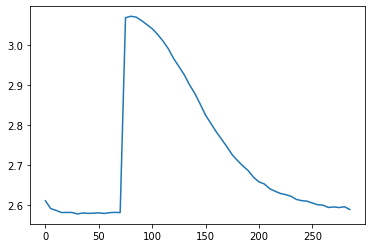

In [4]:
for i, dat in enumerate(all_dat):
    xax = np.arange(0,frameinterval*len(dat.columns),frameinterval)
    datm = dat.to_numpy()
    datm = np.mean(datm,axis=0)
    fig = plt.figure(1)
    fig.clf()
    plt.plot(xax,datm)
    fig.savefig(Path(tau_pth,names[i]+'.png'),dpi=1200)
